# Convolution of Piecewise continuous functions

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
# Course utilities (do not modify this cell)        
import sys
import os
base_path = os.path.expanduser("~/Documents/GitHub/Signals_and_Systems")
sys.path.insert(0, base_path)
sys.path.insert(0, os.path.join(base_path, "courseutils"))

import basic_material as bm
print("Basic Material version:", bm.__version__)
bm.setup_environment()


Basic Material version: 16.002-0.1


In [3]:
colors = bm.get_colors()
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.offsetbox import AnchoredText
import sympy as sp
from sympy import Symbol, oo, integrate, Piecewise, Heaviside, DiracDelta, exp, I, pi, simplify
import control as ct
import control.matlab as cmat

from ipywidgets import interactive

import warnings
warnings.filterwarnings(
    "ignore",
    message="divide by zero encountered in divide"
)
warnings.filterwarnings(
    "ignore",
    message="invalid value encountered in divide"
)

In [4]:
ts = sp.Symbol('t')
# plotting time pts
NN = 10000

## Define Convolution process

In [5]:
def convolve(f, g, t, lower_limit=-oo, upper_limit=oo):
    tau = sp.Symbol('__pick_a_name__', real=True)
    return sp.integrate(f.subs(t, tau) * g.subs(t, t - tau), (tau, lower_limit, upper_limit))

## Define the 2 functions w(t) and g(t)
### Both functions are rectangles - the width and heigtht can be changed here

In [6]:
# w = w_mag for lb_w < t <= ub_w
lb_w = 0
ub_w = 2
w_mag = 0.5

# g = g_mag for lb_g < t <= ub_g
lb_g = 0
ub_g = 3
g_mag = 2

### Given parameters, define the functions and convolve them

In [7]:
# define the functions
w = Piecewise((0, ts <= lb_w),(w_mag, ts <= ub_w),(0, True))
g = Piecewise((0, ts <= lb_g),(g_mag, ts <= ub_g),(0, True))
wg = convolve(w, g, ts)

### Plot the functions to see them

In [8]:
# plotting range of time
tt = np.linspace(lb_w+lb_g-1, ub_w+ub_g+1, NN)

# useful for plotting
lam_w = sp.lambdify(ts, w, modules=['numpy'])
lam_g = sp.lambdify(ts, g, modules=['numpy'])
# regular things doesn't work - try somethng new
lam_wg = sp.lambdify(ts, wg, modules=['numpy'])
# convert for plotting (bit unclear why needed)
newwg = np.zeros((NN,1))
for ii in range(0,NN):
    newwg[ii] = lam_wg(tt[ii])

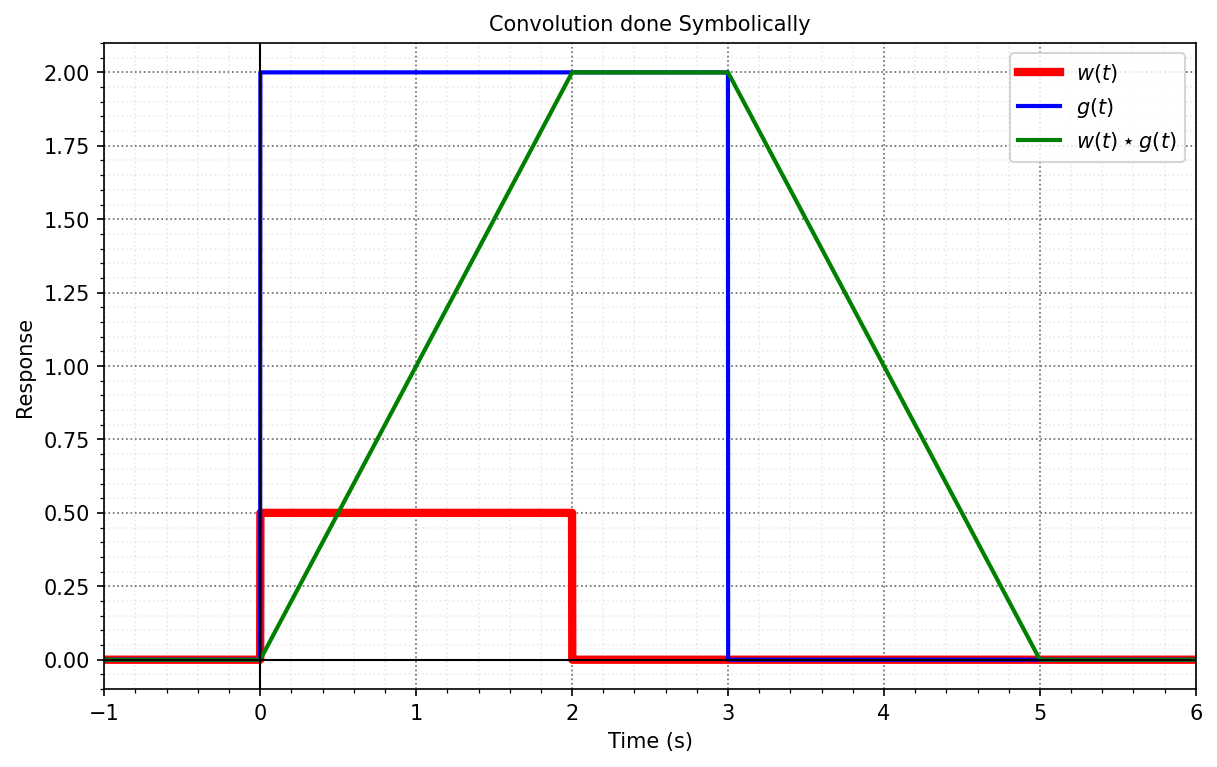

In [9]:
fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
plt.plot(tt, lam_w(tt),'r-',linewidth=4,label='$w(t)$')
plt.plot(tt, lam_g(tt),'b-',linewidth=2,label='$g(t)$')
plt.plot(tt, newwg,'g',linewidth=2,label='$w(t) \star g(t)$')

bm.nicegrid()
plt.legend()
plt.xlim(min(tt),max(tt))
plt.xlabel('Time (s)')
plt.ylabel('Response')
plt.title('Convolution done Symbolically')
plt.show()

In [10]:
def f(lb_w = -1, ub_w = 2, w_mag = 1, lb_g = 0, ub_g = 2):
    # w = w_mag for lb_w < t <= ub_w
    # g = g_mag for lb_g < t <= ub_g
    g_mag = 1
    if w_mag == 0:
        w_mag = 1

    # plotting range of time
    lower = min(lb_w+lb_g,min(lb_w,lb_g))
    upper = max(ub_w+ub_g,max(ub_w,ub_g))
    tt = np.linspace(lower-1, upper+1, NN)

    # define the functions
    w = Piecewise((0, ts <= lb_w),(w_mag, ts <= ub_w),(0, True))
    g = Piecewise((0, ts <= lb_g),(g_mag, ts <= ub_g),(0, True))
    wg = convolve(w, g, ts)

    # useful for plotting
    lam_w = sp.lambdify(ts, w, modules=['numpy'])
    lam_g = sp.lambdify(ts, g, modules=['numpy'])
    # regular things doesn't work - try somethng new
    lam_wg = sp.lambdify(ts, wg, modules=['numpy'])
    newwg = np.zeros((NN,1))
    for ii in range(0,NN):
        newwg[ii] = lam_wg(tt[ii])

    fig = plt.figure(figsize=(8, 5),dpi=150,constrained_layout = True)
    plt.plot(tt, lam_w(tt),'r-',linewidth=4,label='$w(t)$')
    plt.plot(tt, lam_g(tt),'b-',linewidth=2,label='$g(t)$')
    plt.plot(tt, newwg,'g',linewidth=2,label='$w(t) \star g(t)$')

    bm.nicegrid()
    plt.legend()
    plt.xlim(min(tt),max(tt))
    plt.xlabel('Time (s)')
    plt.ylabel('Response')
    plt.title('Convolution done Symbolically')
    plt.show()
    
    return

interactive_plot = interactive(f, {'manual': False}, lb_w=(-1.0, 1.0,1), ub_w=(2.0, 3.0,1), w_mag=(-2.0, 2.0,1), lb_g=(-1.0, 1.0,1), ub_g=(2.0, 4.0,1))
output = interactive_plot.children[-1]
interactive_plot


interactive(children=(FloatSlider(value=-1.0, description='lb_w', max=1.0, min=-1.0, step=1.0), FloatSlider(va…